In [1]:
# This notebook provides a quick and interactive guide to statistical theory.
# It combines concise theoretical explanations with Python visualizations and
# practical examples to facilitate the understanding of key statistical concepts.
#
# Created by:
# Diego Quiguango
# Statistical Engineer
# Email: diegoqfestadistica@gmail.com

In [258]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random
import scipy
from scipy import stats

from google.colab import files

from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
from matplotlib.patches import Polygon

from itertools import product

#Descriptive analysis

In [3]:
random.seed(0)

data = pd.DataFrame({
    'x':np.random.randint(1,100, size=(100)),
    'y':np.random.randint(1,100, size=(100)),
    'z':np.random.randint(0,2, size=(100))
})


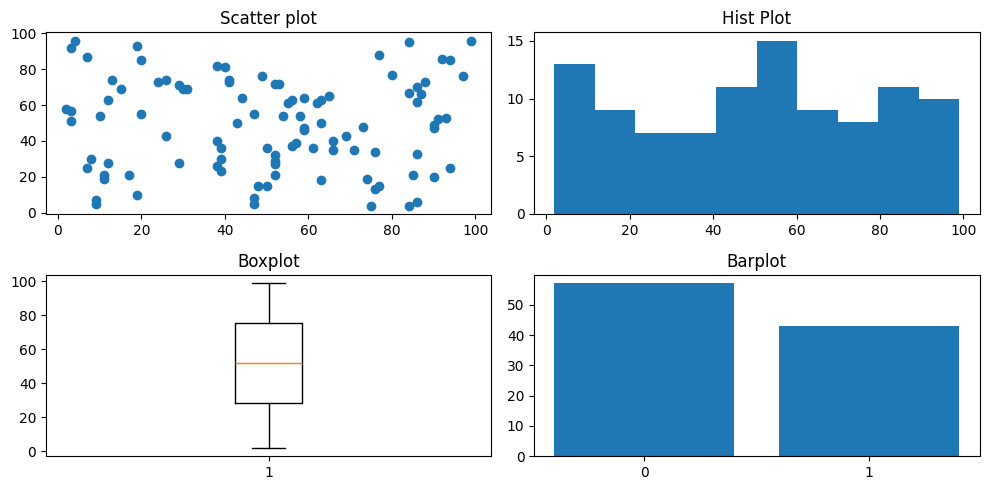

In [4]:
plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.scatter(data['x'], data['y'])
plt.title('Scatter plot')

plt.subplot(2,2,2)
plt.hist(data['x'])
plt.title('Hist Plot')

plt.subplot(2,2,3)
plt.boxplot(data['x'])
plt.title('Boxplot')

plt.subplot(2,2,4)
plt.bar(x=['0','1'], height=data['z'].value_counts())
plt.title('Barplot')

plt.tight_layout()
plt.show()


In [5]:
data['z'].value_counts()

,count
z,
0,57
1,43


In [6]:
data.drop('z', axis=1).describe().round(4)

,x,y
count,100.0000,100.000
mean,50.7600,48.640
std,28.2321,25.487
min,2.0000,4.000
25%,28.2500,27.750
50%,52.0000,50.000
75%,75.2500,69.250
max,99.0000,96.000


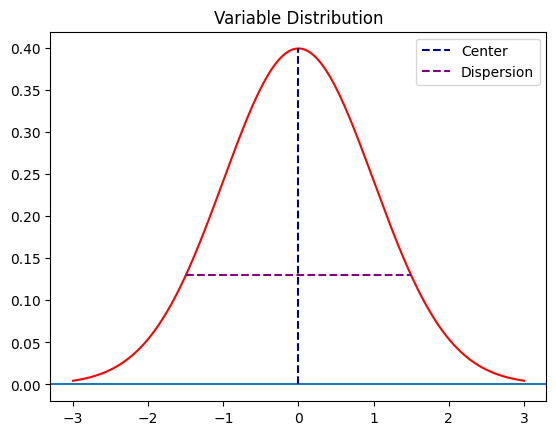

In [7]:
x = np.linspace(-3, 3, 1000)
y = scipy.stats.norm.pdf(x)

plt.plot(x, y, color='red')
plt.axhline()
plt.vlines(x=0, ymin=0, ymax=scipy.stats.norm.pdf(0),
           linestyles='dashed', label='Center', color='darkblue')
plt.hlines(y=scipy.stats.norm.pdf(-1.5), xmin=-1.5, xmax=1.5,
           linestyles='dashed', label='Dispersion', color='purple')
plt.title('Variable Distribution')

plt.legend()

plt.show()

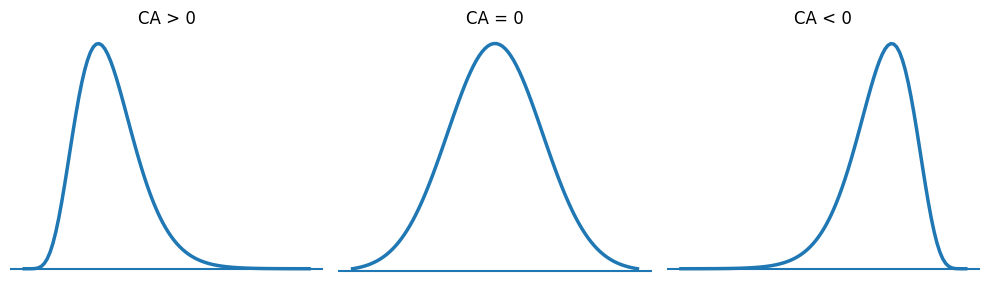

In [8]:
nvalues = 100
df = 15

plt.figure(figsize=(10, 3))

xnorm = np.linspace(-3, 3, nvalues)
xchi2 = np.linspace(0, 50, nvalues)
y1 = scipy.stats.norm.pdf(xnorm)
y2 = scipy.stats.chi2.pdf(xchi2, df=df)

plt.subplot(1,3,1)
plt.plot(xchi2, y2,  linewidth=2.5)
plt.axis('off')
# plt.vlines(np.mean(xchi2), ymin=0, ymax=scipy.stats.chi2.pdf(np.mean(xchi2), df=df),
#            linestyles='dashed', color='red', label='Mean')
# plt.vlines(np.median(xchi2)-5, ymin=0, ymax=scipy.stats.chi2.pdf(np.median(xchi2)-5, df=df),
#            linestyles='dashed', color='blue', label='Median')
plt.axhline(0)
# plt.legend(fontsize=25)
plt.title('CA > 0')

plt.subplot(1,3,2)
plt.plot(xnorm, y1, linewidth=2.5)
plt.axis('off')
# plt.vlines(0, ymin=0, ymax=scipy.stats.norm.pdf(np.mean(xnorm)),
#            linestyles='dashed', color='red', label='Mean')
# plt.vlines(0, ymin=0, ymax=scipy.stats.norm.pdf(np.median(xnorm)),
#            linestyles='dashed', color='blue', label='Median')
plt.axhline(0)
plt.title('CA = 0')

plt.subplot(1,3,3)
plt.plot(-xchi2, y2, linewidth=2.5)
plt.axis('off')
plt.axhline(0)
# plt.vlines(-np.mean(xchi2), ymin=0, ymax=scipy.stats.chi2.pdf(np.mean(xchi2), df=df),
#            linestyles='dashed', color='red', label='Mean')
# plt.vlines(-np.median(xchi2)+5, ymin=0, ymax=scipy.stats.chi2.pdf(np.median(xchi2)-5, df=df),
#            linestyles='dashed', color='blue', label='Median')
plt.title('CA < 0')

plt.tight_layout()

plt.show()

[]

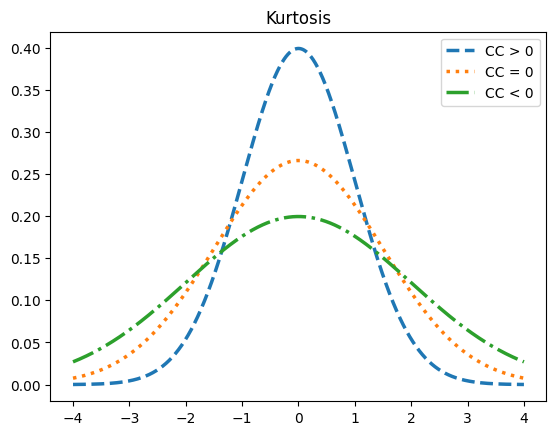

In [9]:
r = [-4, 4]
nvalues = 1000
df = [10000, 10, 5]

x = np.linspace(r[0], r[1], nvalues)
y1 = scipy.stats.norm.pdf(x, loc=0, scale=1)
y2 = scipy.stats.norm.pdf(x, loc=0, scale=1.5)
y3 = scipy.stats.norm.pdf(x, loc=0, scale=2)

plt.subplot(1,1,1)
plt.plot(x, y1, label='CC > 0', linestyle='--', linewidth=2.5)
plt.subplot(1,1,1)
plt.plot(x, y2, label='CC = 0', linestyle=':', linewidth=2.5)
plt.subplot(1,1,1)
plt.plot(x, y3, label='CC < 0', linestyle='-.', linewidth=2.5)

plt.title('Kurtosis')

plt.legend(fontsize=10)

plt.plot()

In [10]:
[i for i in np.arange(0, 1, 0.25)+.25]

[np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]

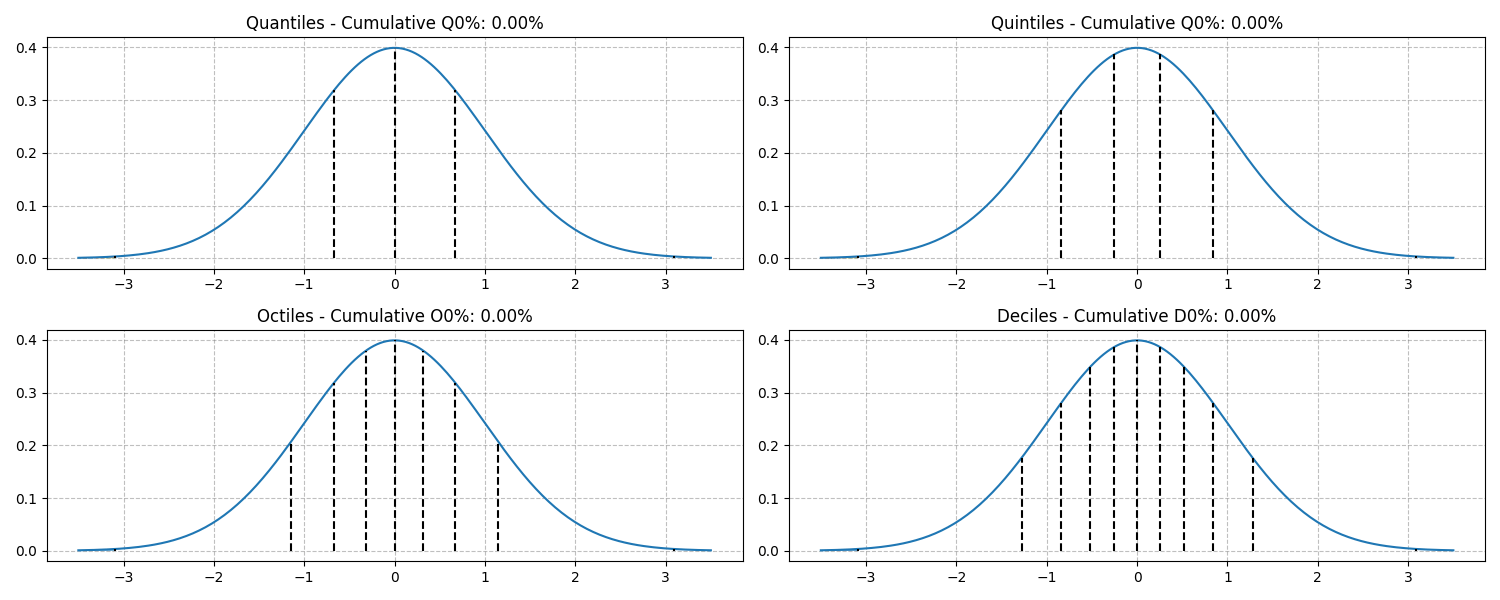

In [11]:
# Cuantiles

z = np.linspace(-3.5, 3.5, 200)
pdf = stats.norm.pdf(z, loc=0, scale=1)

fig, ax = plt.subplots(2, 2, figsize=(15, 6))

colors = ['#F5C227', '#9FF527', '#27D6F5', '#6127F5']

# STATIC COMPONENTS
# MAIN FIGURE
for i in product(range(0,2), range(0,2)):
  ax[i[0], i[1]].plot(z, pdf)
  ax[i[0], i[1]].grid(alpha=0.5, color='grey', linestyle='--')

ax[0, 0].set_title('Quartiles')
ax[0, 1].set_title('Quintiles')
ax[1, 0].set_title('Octiles')
ax[1, 1].set_title('Deciles')

# Cuantiles
c = np.linspace(0.001, 0.999, 5)
q = np.linspace(0.001, 0.999, 6)
o = np.linspace(0.001, 0.999, 9)
d = np.linspace(0.001, 0.999, 11)

# Cumulative %
cum_c = np.linspace(0, 1, 5) * 100
cum_q = np.linspace(0, 1, 6) * 100
cum_o = np.linspace(0, 1, 9) * 100
cum_d = np.linspace(0, 1, 11) * 100

# Z modifiable values
z_c = stats.norm.ppf(c)
z_q = stats.norm.ppf(q)
z_o = stats.norm.ppf(o)
z_d = stats.norm.ppf(d)

# Probability values
p_c = stats.norm.pdf(z_c)
p_q = stats.norm.pdf(z_q)
p_o = stats.norm.pdf(z_o)
p_d = stats.norm.pdf(z_d)


# COORDINATES
x_c = np.r_[z_c[0], z_c, z_c[-1]]
x_q = np.r_[z_q[0], z_q, z_q[-1]]
x_o = np.r_[z_o[0], z_o, z_o[-1]]
x_d = np.r_[z_d[0], z_d, z_d[-1]]

y_c = stats.norm.pdf(x_c)
y_q = stats.norm.pdf(x_q)
y_o = stats.norm.pdf(x_o)
y_d = stats.norm.pdf(x_d)

# Thresholds between quantiles
for i in np.column_stack([z_c, p_c]):
  ax[0, 0].plot([i[0], i[0]], [0, i[1]], color='black', linestyle='--')

for i in np.column_stack([z_q, p_q]):
  ax[0, 1].plot([i[0], i[0]], [0, i[1]], color='black', linestyle='--')

for i in np.column_stack([z_o, p_o]):
  ax[1, 0].plot([i[0], i[0]], [0, i[1]], color='black', linestyle='--')

for i in np.column_stack([z_d, p_d]):
  ax[1, 1].plot([i[0], i[0]], [0, i[1]], color='black', linestyle='--')


pol_c = Polygon([[z[0],0], [z[0],0]])
pol_q = Polygon([[z[0],0], [z[0],0]])
pol_o = Polygon([[z[0],0], [z[0],0]])
pol_d = Polygon([[z[0],0], [z[0],0]])

pol_c.set_facecolor(colors[0])
pol_q.set_facecolor(colors[1])
pol_o.set_facecolor(colors[2])
pol_d.set_facecolor(colors[3])


ax[0, 0].add_patch(pol_c)
ax[0, 1].add_patch(pol_q)
ax[1, 0].add_patch(pol_o)
ax[1, 1].add_patch(pol_d)

plt.tight_layout()



def update(frame):

  # QUARTILES
  if frame < len(z_c):
      pol_c.set_xy(
          np.column_stack([
              np.r_[z[0], z[:np.searchsorted(z, z_c[frame]) + 1], z_c[frame]],
              np.r_[0, pdf[:np.searchsorted(z, z_c[frame]) + 1], 0]
          ])
      )
      ax[0,0].set_title(f'Quantiles - Cumulative Q{frame}%: {cum_c[frame]:.2f}%')

  # QUINTILES
  if frame < len(z_q):
      pol_q.set_xy(
          np.column_stack([
              np.r_[z[0], z[:np.searchsorted(z, z_q[frame]) + 1], z_q[frame]],
              np.r_[0, pdf[:np.searchsorted(z, z_q[frame]) + 1], 0]
          ])
      )
      ax[0,1].set_title(f'Quintiles - Cumulative Q{frame}%: {cum_q[frame]:.2f}%')

  # OCTILES
  if frame < len(z_o):
      pol_o.set_xy(
          np.column_stack([
              np.r_[z[0], z[:np.searchsorted(z, z_o[frame]) + 1], z_o[frame]],
              np.r_[0, pdf[:np.searchsorted(z, z_o[frame]) + 1], 0]
          ])
      )
      ax[1,0].set_title(f'Octiles - Cumulative O{frame}%: {cum_o[frame]:.2f}%')

  # DECILES
  if frame < len(z_d):
      pol_d.set_xy(
          np.column_stack([
              np.r_[z[0], z[:np.searchsorted(z, z_d[frame]) + 1], z_d[frame]],
              np.r_[0, pdf[:np.searchsorted(z, z_d[frame]) + 1], 0]
          ])
      )
      ax[1,1].set_title(f'Deciles - Cumulative D{frame}%: {cum_d[frame]:.2f}%')

  return pol_c, pol_q, pol_o, pol_d

animation = FuncAnimation(
    fig=fig,
    func=update,
    frames=30,
    interval=500,
    repeat=False
)

animation.save(
    filename='Density plot.gif',
    writer='pillow',
    fps=3
)

plt.close(fig)

display(Image(filename='Density plot.gif'))

In [12]:
for i in np.column_stack([x_c, y_c]):
  print(i)

[-3.09023231  0.00336709]
[-3.09023231  0.00336709]
[-0.67291715  0.31811342]
[0.         0.39894228]
[0.67291715 0.31811342]
[3.09023231 0.00336709]
[3.09023231 0.00336709]


In [13]:
# Tablas de frecuencia
random.seed(123)

state = np.array(random.choices(['sick', 'not sick'], k=100))
exposure = np.array(random.choices(['exposed', 'not exposed'], k=100))

In [14]:
tabla = pd.DataFrame(pd.Series(state).value_counts())
tabla['acum_count'] = np.cumsum(tabla['count'])
tabla['percent'] = tabla['count'] / np.sum(tabla['count']) *100
tabla['acum_percent'] = np.cumsum(tabla['percent'])


tabla

,count,acum_count,percent,acum_percent
sick,61,61,61.0,61.0
not sick,39,100,39.0,100.0


In [15]:
pd.crosstab(state, exposure)

col_0,exposed,not exposed
row_0,,
not sick,16,23
sick,30,31


In [16]:
random.seed(123)
pd.Series(np.array(random.choices(range(20,71), k=50))).describe()

,0
count,50.000000
mean,42.320000
std,14.705878
min,20.000000
25%,29.250000
50%,41.000000
75%,54.000000
max,66.000000


#Data Visualization

##Cuantitative variables


In [17]:
from sklearn import datasets

Info for features of the dataset is presented here:

- radius (mean of distances from center to points on the perimeter)

- texture (standard deviation of gray-scale values)

- perimeter

- area

- smoothness (local variation in radius lengths)

- compactness (perimeter^2 / area - 1.0)

- concavity (severity of concave portions of the contour)

- concave points (number of concave portions of the contour)

- symmetry

- fractal dimension (“coastline approximation” - 1)  
The mean, standard error, and “worst” or largest (mean of the three worst/largest values) of these features were computed for each image, resulting in 30 features. For instance, field 0 is Mean Radius, field 10 is Radius SE, field 20 is Worst Radius.

- class:  
WDBC-Malignant (1)  
WDBC-Benign (0)

In [18]:
cancer = datasets.load_breast_cancer(as_frame=True)
cancer = cancer.frame
cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [19]:
cancer['target'] = cancer['target'].replace({1:'WDBS-Benign', 0:'WDBC-Malignant'})

In [20]:
cancer['target'].value_counts().values

array([357, 212])

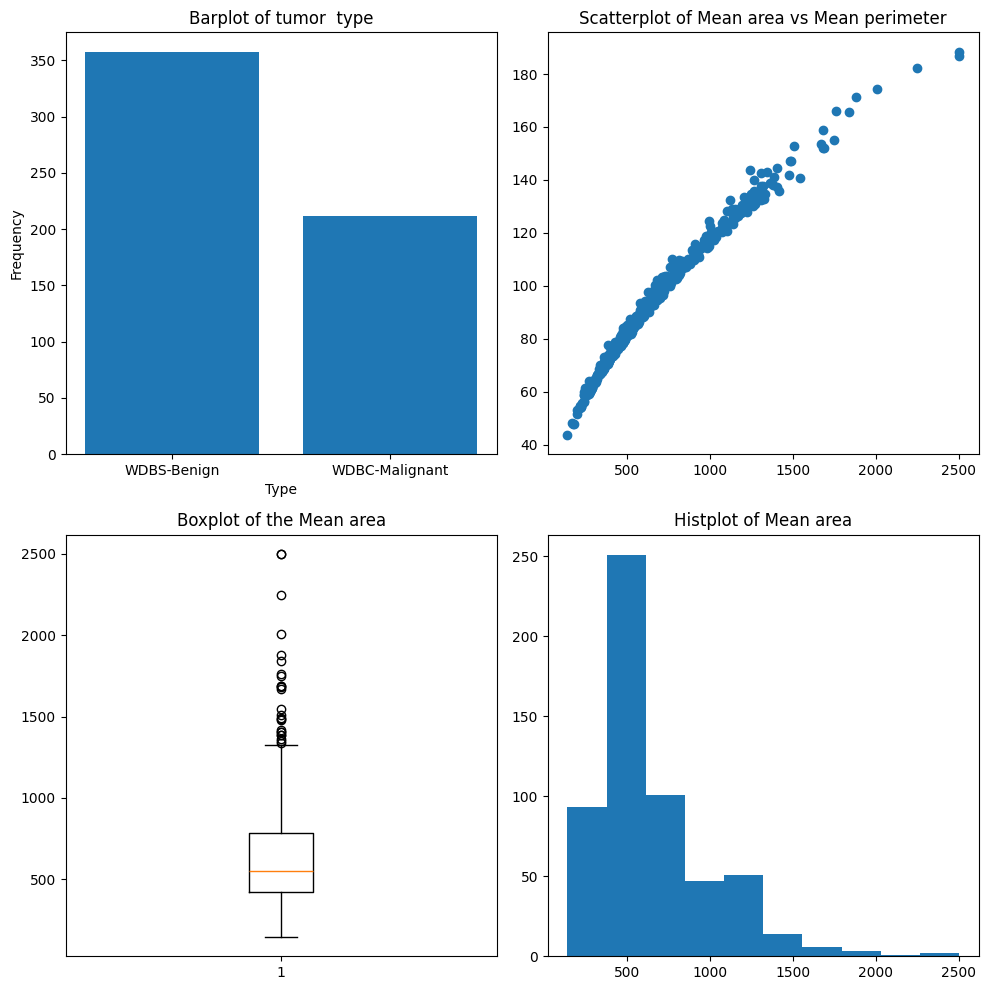

In [21]:
# Combined graph
plt.figure(figsize=(10,10))

plt.subplot(2,2,1)
plt.bar(x=cancer['target'].value_counts().index,
        height=cancer['target'].value_counts().values)
plt.title('Barplot of tumor  type')
plt.xlabel('Type')
plt.ylabel('Frequency')

plt.subplot(2,2,2)
plt.scatter(cancer['mean area'], cancer['mean perimeter'])
plt.title('Scatterplot of Mean area vs Mean perimeter')

plt.subplot(2,2,3)
plt.boxplot(cancer['mean area'])
plt.title('Boxplot of the Mean area')

plt.subplot(2,2,4)
plt.hist(cancer['mean area'])
plt.title('Histplot of Mean area')

plt.tight_layout()

plt.show()

In [22]:
sex = np.array(random.choices(['Men', 'Women'], k=cancer.shape[0]))

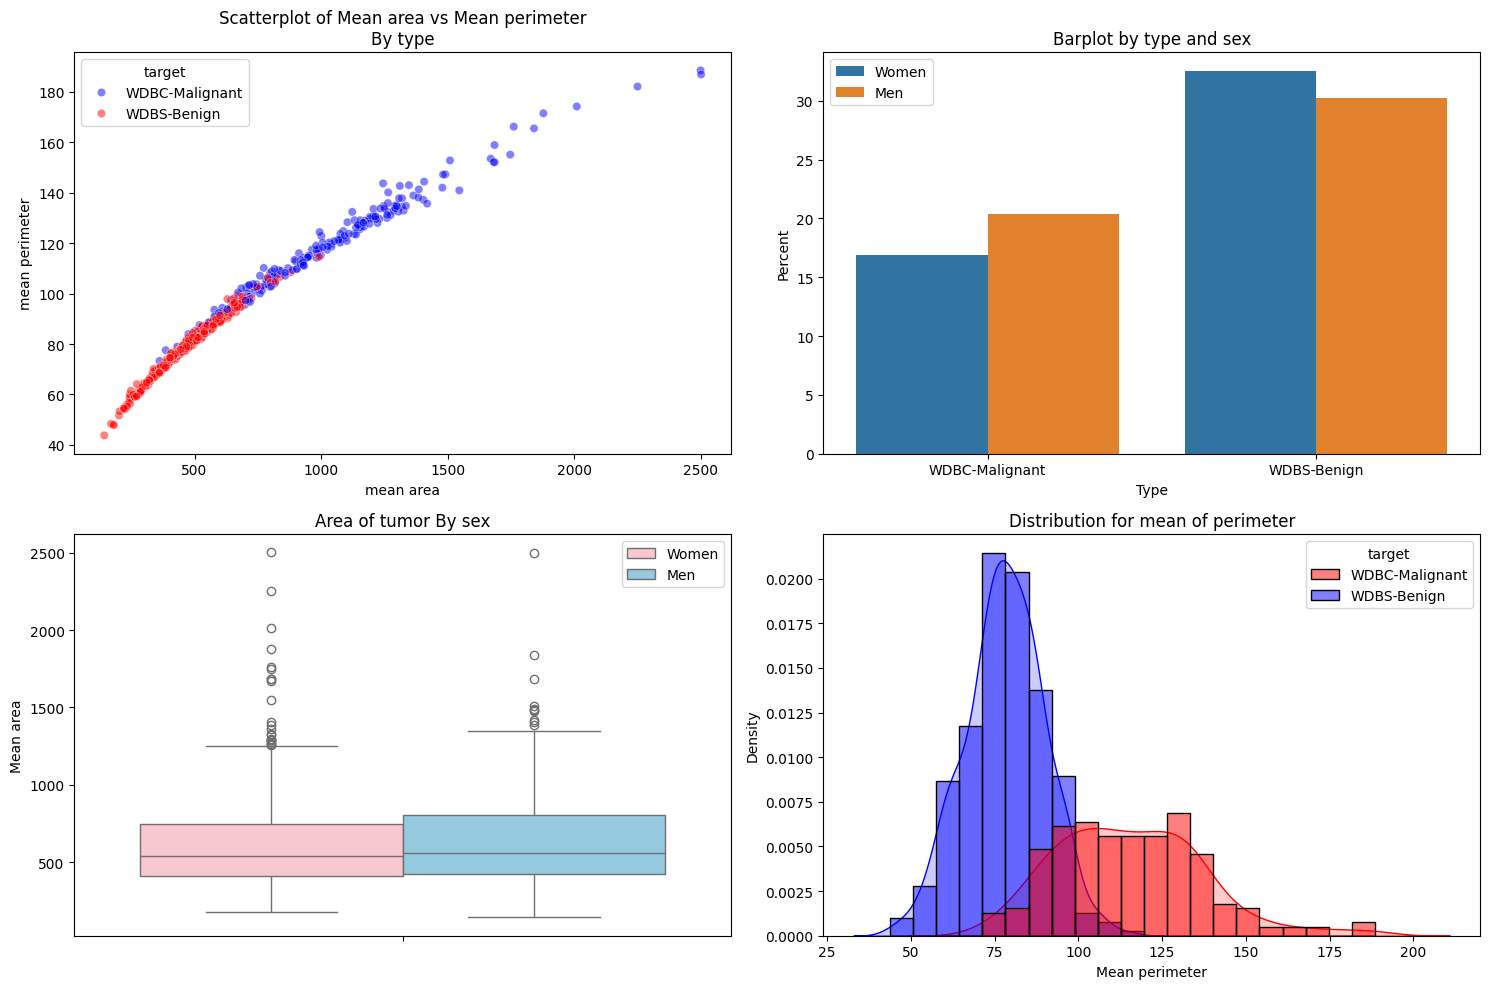

In [23]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
sns.scatterplot(cancer, x='mean area', y='mean perimeter', hue='target',
                palette=['blue', 'red'], alpha=0.5)
plt.title('Scatterplot of Mean area vs Mean perimeter\nBy type')


plt.subplot(2,2,2)
sns.countplot(data=cancer, x='target', hue=sex, stat='percent')
plt.title('Barplot by type and sex')
plt.xlabel('Type')
plt.ylabel('Percent')

plt.subplot(2,2,3)
sns.boxplot(data=cancer, y='mean area', hue=sex, palette=['pink', 'skyblue'])
plt.title('Area of tumor By sex')
plt.ylabel('Mean area')

plt.subplot(2,2,4)
sns.kdeplot(data=cancer, x='mean perimeter', hue='target', palette=['red', 'blue'],
            fill=['red', 'blue'], alpha=0.2)
sns.histplot(data=cancer, x='mean perimeter', hue='target', palette=['red', 'blue'],
             fill=['red', 'blue'], alpha=0.5, stat='density')
plt.title('Distribution for mean of perimeter')
plt.xlabel('Mean perimeter')

plt.tight_layout()

plt.show()

In [24]:
!pip install -q geopandas geodatasets

In [25]:
import geopandas as gdp
import geodatasets

In [26]:
url_ecuador = 'https://data.humdata.org/dataset/e66dbc70-17fe-4230-b9d6-855d192fc05c/resource/6fa37b41-ad28-40a6-9641-3b4efd4dbe13/download/ecuador.geojson'
ecuador = gdp.read_file(url_ecuador)

In [27]:
ecuador[['DPA_DESPRO', 'geometry']]

,DPA_DESPRO,geometry
0,AZUAY,"MULTIPOLYGON (((-79.39303 -2.49798, -79.39052 ..."
1,AZUAY,"MULTIPOLYGON (((-79.02892 -3.17588, -79.02701 ..."
2,AZUAY,"MULTIPOLYGON (((-78.63193 -2.93822, -78.63687 ..."
3,AZUAY,"MULTIPOLYGON (((-78.93581 -3.28822, -78.93412 ..."
4,AZUAY,"MULTIPOLYGON (((-78.6419 -2.72233, -78.64778 -..."
...,...,...
219,SANTA ELENA,"MULTIPOLYGON (((-80.87062 -2.27018, -80.87315 ..."
220,SANTA ELENA,"MULTIPOLYGON (((-80.922 -2.21943, -80.92059 -2..."
221,ZONA NO DELIMITADA,"MULTIPOLYGON (((-78.92286 0.35833, -78.92784 0..."
222,ZONA NO DELIMITADA,"MULTIPOLYGON (((-79.45992 -0.50373, -79.45941 ..."


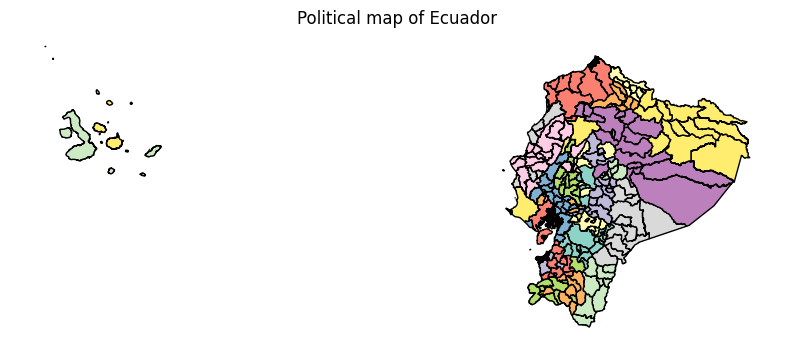

In [28]:
fig, ax = plt.subplots(figsize=(10,8))
ecuador.plot(ax=ax, edgecolor='black', cmap='Set3')

plt.title('Political map of Ecuador')

plt.axis('off')

plt.show()

[]

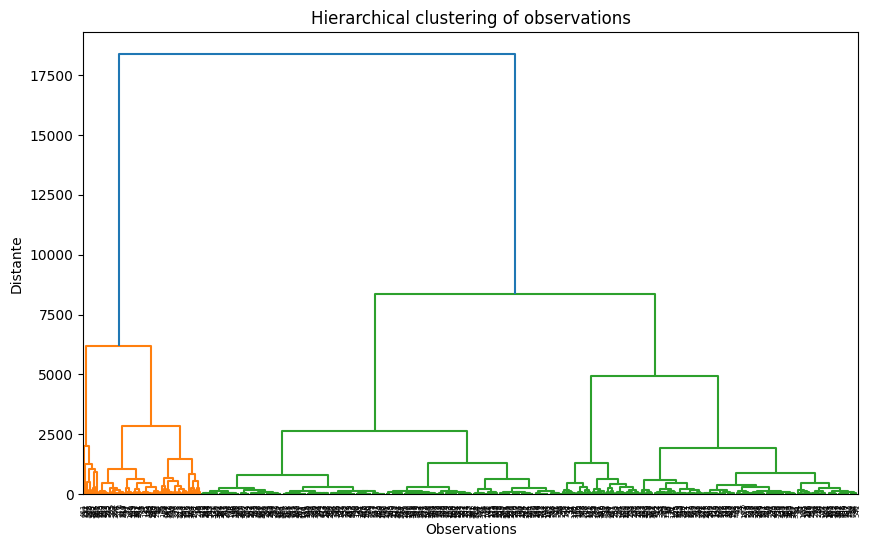

In [29]:
# Dendrogram
Z = scipy.cluster.hierarchy.linkage(cancer.drop('target', axis=1), method='ward')

plt.figure(figsize=(10,6))

scipy.cluster.hierarchy.dendrogram(Z)

plt.title('Hierarchical clustering of observations')
plt.ylabel('Distante')
plt.xlabel('Observations')

plt.plot()

Text(0.5, 1.0, 'Heatmap')

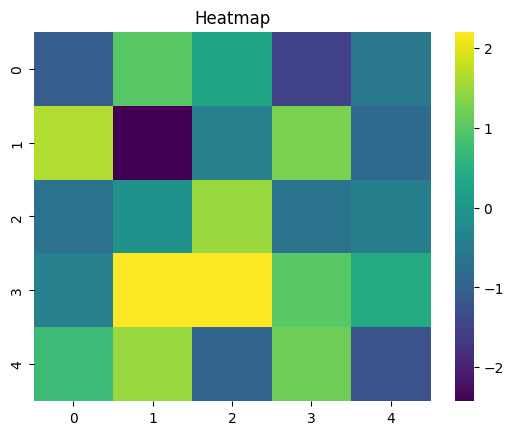

In [30]:
# Heatmap

np.random.seed(123)

sns.heatmap(np.random.randn(5,5), cmap='viridis')
plt.title('Heatmap')

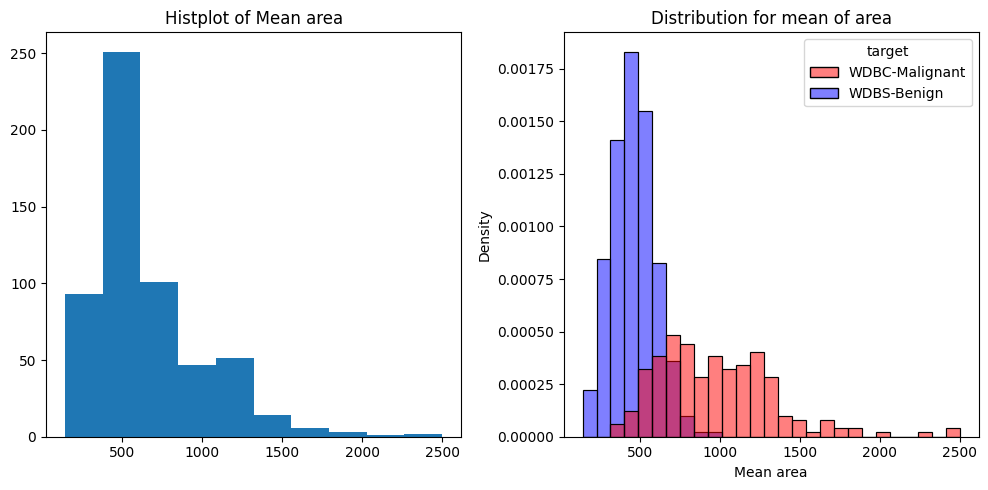

In [31]:
# Histplot

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(cancer['mean area'])
plt.title('Histplot of Mean area')

plt.subplot(1,2,2)
# sns.kdeplot(data=cancer, x='mean perimeter', hue='target', palette=['red', 'blue'], fill=['red', 'blue'], alpha=0.2)
sns.histplot(data=cancer, x='mean area', hue='target', palette=['red', 'blue'], fill=['red', 'blue'], alpha=0.5, stat='density')
plt.title('Distribution for mean of area')
plt.xlabel('Mean area')

plt.tight_layout()

plt.show()


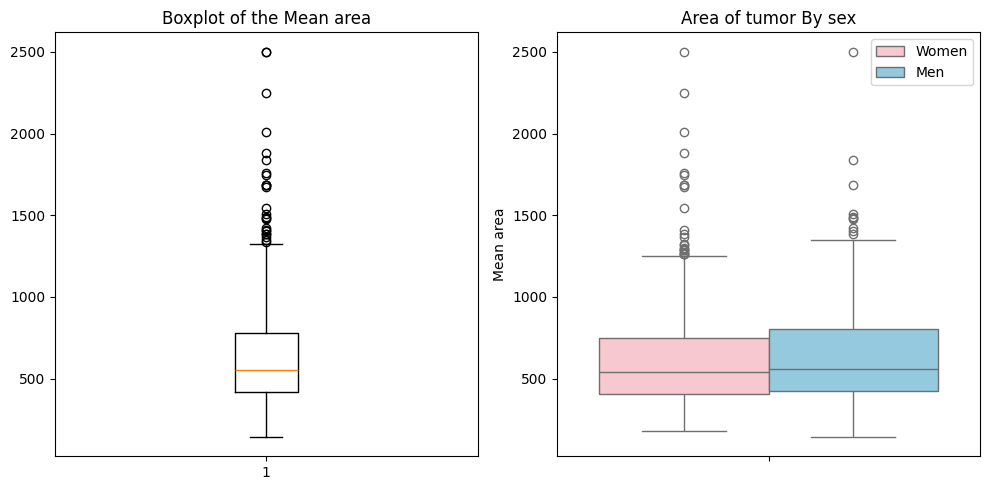

In [32]:
# Boxplot

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.boxplot(cancer['mean area'])
plt.title('Boxplot of the Mean area')

plt.subplot(1,2,2)
sns.boxplot(data=cancer, y='mean area', hue=sex, palette=['pink', 'skyblue'])
plt.title('Area of tumor By sex')
plt.ylabel('Mean area')

plt.tight_layout()

plt.show()

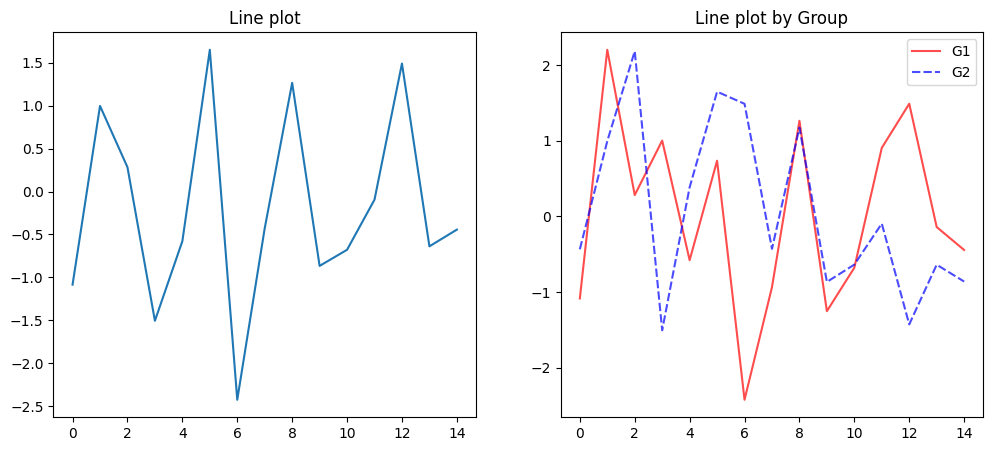

In [33]:
# Line plot

plt.figure(figsize=(12,5))

np.random.seed(123)
values1 = np.random.randn(15)
values2 = np.random.randn(15)

plt.subplot(1,2,1)
plt.plot(range(values1.shape[0]), values1)
plt.title('Line plot')

plt.subplot(1,2,2)
sns.lineplot(x = [i for i in range(values1.shape[0])] * 2, y=np.concat([values1, values2]),
             hue=['G1' if i%2==0 else 'G2' for i in range(np.concat([values1, values2]).shape[0])],
             palette=['red','blue'], alpha=0.7,
             style=['G1' if i%2==0 else 'G2' for i in range(np.concat([values1, values2]).shape[0])])
plt.title('Line plot by Group')


plt.show()

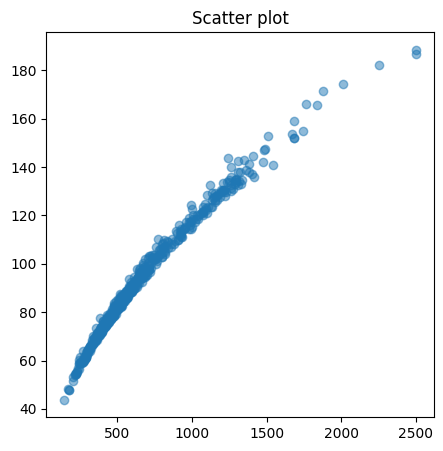

In [34]:
# Scatter plot

plt.figure(figsize=(5,5))

plt.scatter(cancer['mean area'], cancer['mean perimeter'], alpha=0.5)
plt.title('Scatter plot')

plt.show()

Text(0.5, 1.0, 'Heatmap')

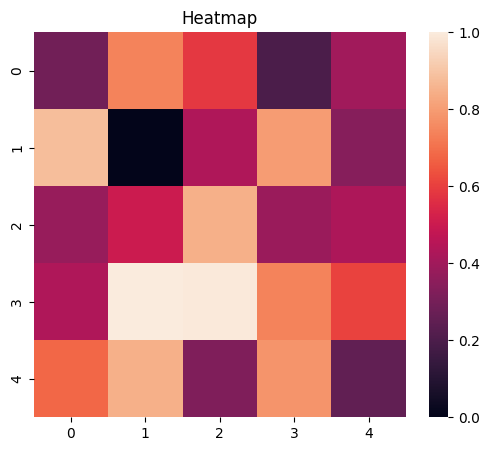

In [35]:
# Heatmap

np.random.seed(123)

matriz = np.random.randn(5,5)
matriz = (matriz - np.min(matriz)) / (np.max(matriz) - np.min(matriz))

plt.figure(figsize=(6, 5))
sns.heatmap(matriz)
plt.title('Heatmap')


<Figure size 600x500 with 0 Axes>

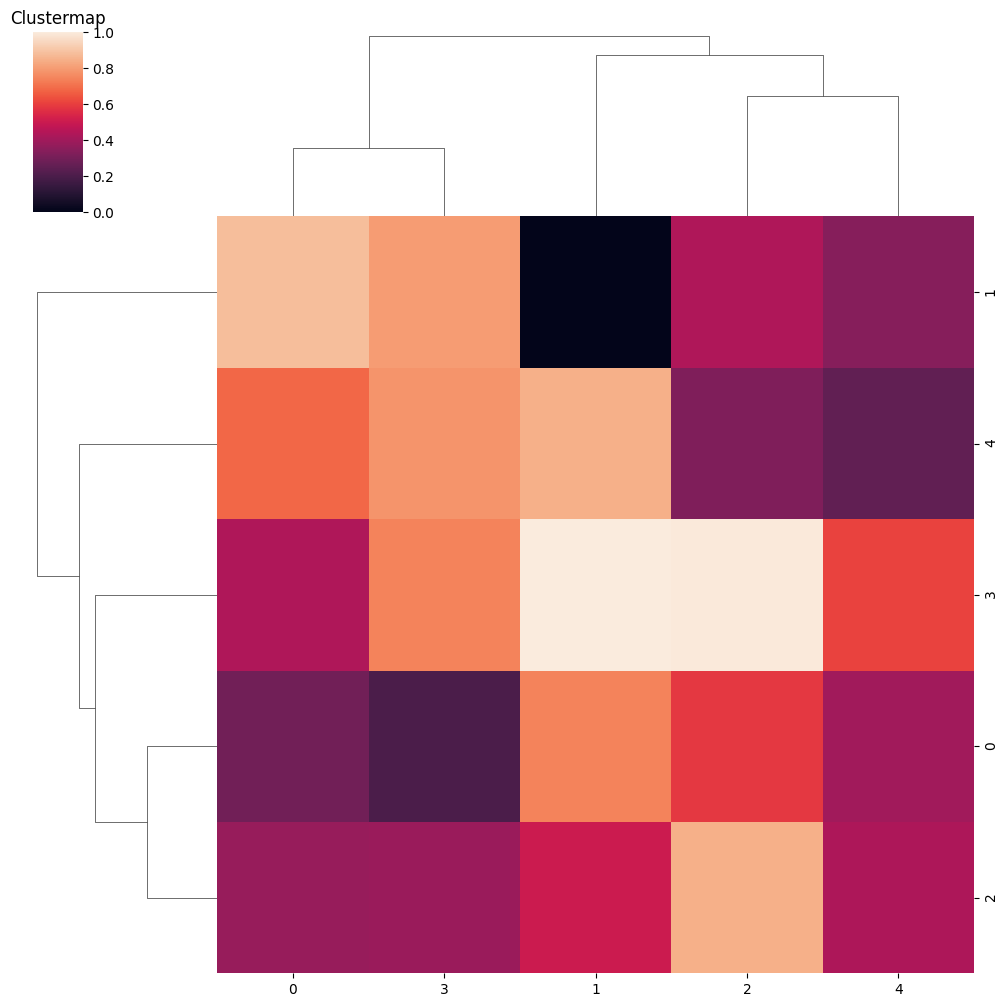

In [36]:
# Clustermap

plt.figure(figsize=(6, 5))
sns.clustermap(matriz)
plt.title('Clustermap')

plt.show()

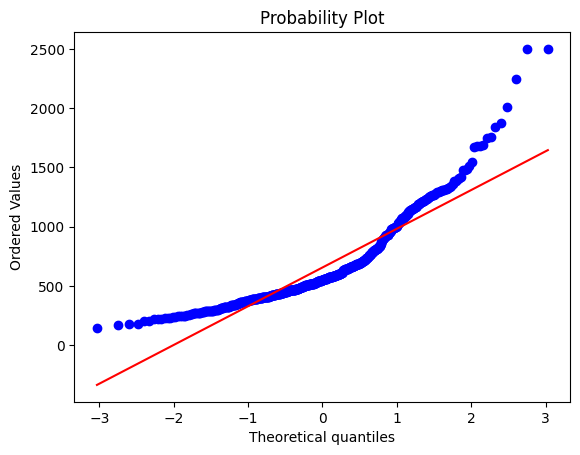

In [37]:
# Q-Q plot

import pylab

scipy.stats.probplot(cancer['mean area'], plot=pylab)
plt.show()


##Cualitative variables

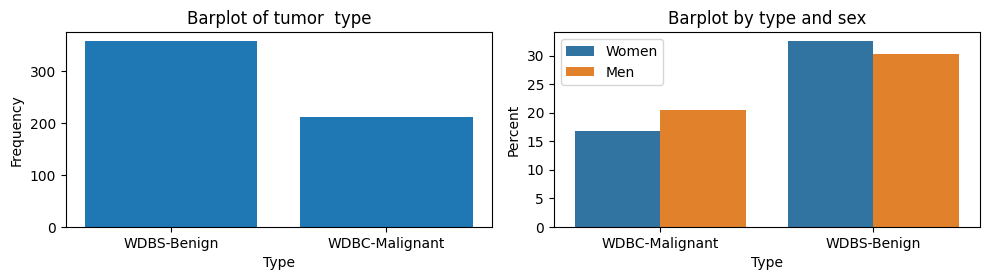

In [38]:
# Barplot

plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.bar(x=cancer['target'].value_counts().index,
        height=cancer['target'].value_counts().values)
plt.title('Barplot of tumor  type')
plt.xlabel('Type')
plt.ylabel('Frequency')

plt.subplot(2,2,2)
sns.countplot(data=cancer, x='target', hue=sex, stat='percent')
plt.title('Barplot by type and sex')
plt.xlabel('Type')
plt.ylabel('Percent')

plt.tight_layout()

plt.show()

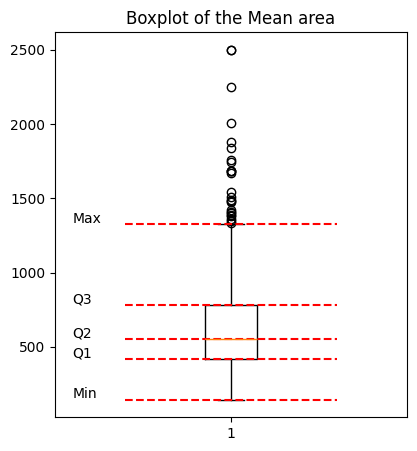

In [39]:
c = np.quantile(cancer['mean area'], q=[0, 0.25, 0.5, 0.75])
ri = c[3] - c[1]
maxNoOutliers = np.max(
    cancer['mean area'].values[np.logical_and(cancer['mean area'].values>=(c[1]-1.5*ri),
                                              cancer['mean area'].values<=(c[3]+1.5*ri))])

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.boxplot(cancer['mean area'])
plt.title('Boxplot of the Mean area')
plt.plot(
    [0.7, 1.3], [c[0]]*2,
    [0.7, 1.3], [c[1]]*2,
    [0.7, 1.3], [c[2]]*2,
    [0.7, 1.3], [c[3]]*2,
    [0.7, 1.3], [maxNoOutliers]*2,
    linestyle='--', color='red')
plt.text(0.55, c[0]+10, 'Min')
plt.text(0.55, c[1]+10, 'Q1')
plt.text(0.55, c[2]+10, 'Q2')
plt.text(0.55, c[3]+10, 'Q3')
plt.text(0.55, maxNoOutliers+10, 'Max', color='black')

plt.show()

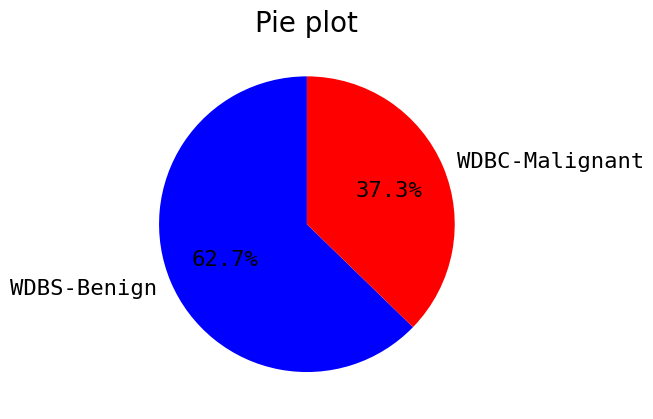

In [40]:
plt.pie(x=cancer['target'].value_counts().values,
        labels=cancer['target'].value_counts().index, autopct='%1.1f%%',
        startangle=90, colors=['blue','red'],
        textprops={'fontsize':16,
                   'fontfamily':'monospace'})
plt.title('Pie plot', fontsize=20)

plt.rcdefaults()

plt.show()

<Figure size 800x600 with 0 Axes>

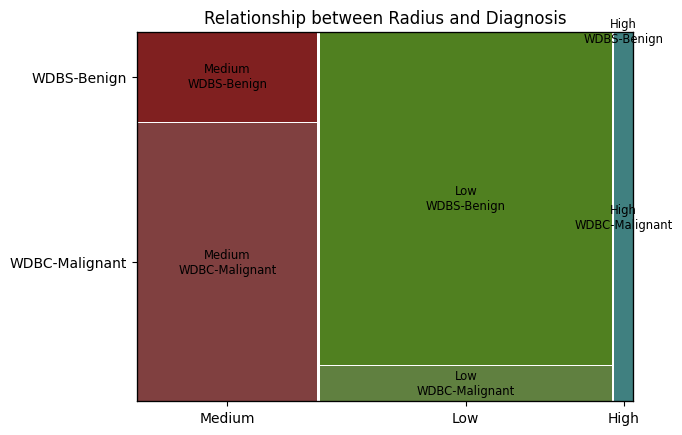

In [41]:
from statsmodels.graphics.mosaicplot import mosaic

# Convert a quantitative variable into categories
cancer['radius_category'] = pd.cut(
    cancer['mean radius'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

# Mosaic plot
plt.figure(figsize=(8, 6))

mosaic(
    cancer,
    ['radius_category', 'target'],
    title='Relationship between Radius and Diagnosis'
)

plt.show()

# Probability

##Density function

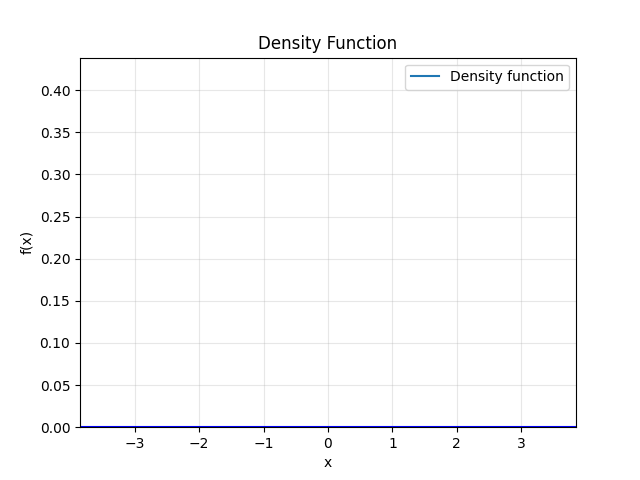

In [42]:
fig, ax = plt.subplots()

# 1. Defining the data
x = np.linspace(-3.5, 3.5, 200)
y = scipy.stats.norm.pdf(x)


# 2. Static aspects of the plot
ax.axhline(0, color='blue')

ax.set_ylim(0, np.max(y) * 1.1)
ax.set_xlim(np.min(x) * 1.1, np.max(x) * 1.1)
ax.set_title('Density Function')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.grid(alpha=0.3)

# 3. Dynamic components
p_line, = ax.plot(
    [],
    [],
    label='Density function'
)

ax.legend()


# 4. Defining the update function
def update(frame):

    x_coords = x[:frame + 1]
    y_coords = y[:frame + 1]

    p_line.set_data(
        x_coords,
        y_coords
    )

    return p_line,


# 5. Creating the animation
animation = FuncAnimation(
    fig=fig,
    func=update,
    frames=len(x),
    interval=30,
    blit=True,
    repeat=True
)


# 6. Exporting the figure
animation.save(
    filename='Density plot.gif',
    writer='pillow',
    fps=30
)

plt.close()

# 7. Displaying the figure
display(Image(filename='Density plot.gif'))


##Density and distribution function

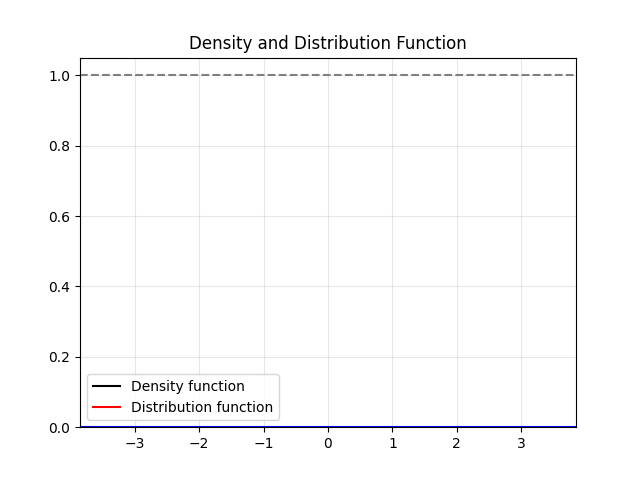

In [43]:
fig, ax = plt.subplots()

# 1. Defining the data
x = np.linspace(-3.5, 3.5, 200)
pdf = scipy.stats.norm.pdf(x)
cdf = scipy.stats.norm.cdf(x)


# 2. Static aspects of the plot
ax.axhline(0, color='blue')
ax.set_ylim(0, 1.05)
ax.set_xlim(np.min(x) * 1.1, np.max(x) * 1.1)
ax.axhline(1, color='grey', linestyle='--')
ax.set_title('Density and Distribution Function')
ax.grid(alpha=0.3)


# 3. Dynamic components
pdf_line, = ax.plot([], [], label='Density function', color='black');
cdf_line, = ax.plot([], [], label='Distribution function', color='red');
ax.legend()

# 4. Defining the update function
def update(frame):

  x_coords = x[:frame]
  pdf_coords = pdf[:frame]
  cdf_coords = cdf[:frame]

  pdf_line.set_data(x_coords, pdf_coords)
  cdf_line.set_data(x_coords, cdf_coords)

  return pdf_line, cdf_line,

# 5. Creating the animation
animation = FuncAnimation(
    fig = fig,
    func = update,
    frames = len(x),
    interval = 1,
    blit = True,
    repeat = True
)

# 6. Exporting the figure
animation.save(filename='Density and distribution.gif',
               writer='pillow',
               fps=40)

plt.close(fig)


# 7. Displaying the figure
display(Image(filename='Density and distribution.gif'))

##Discrete distributions

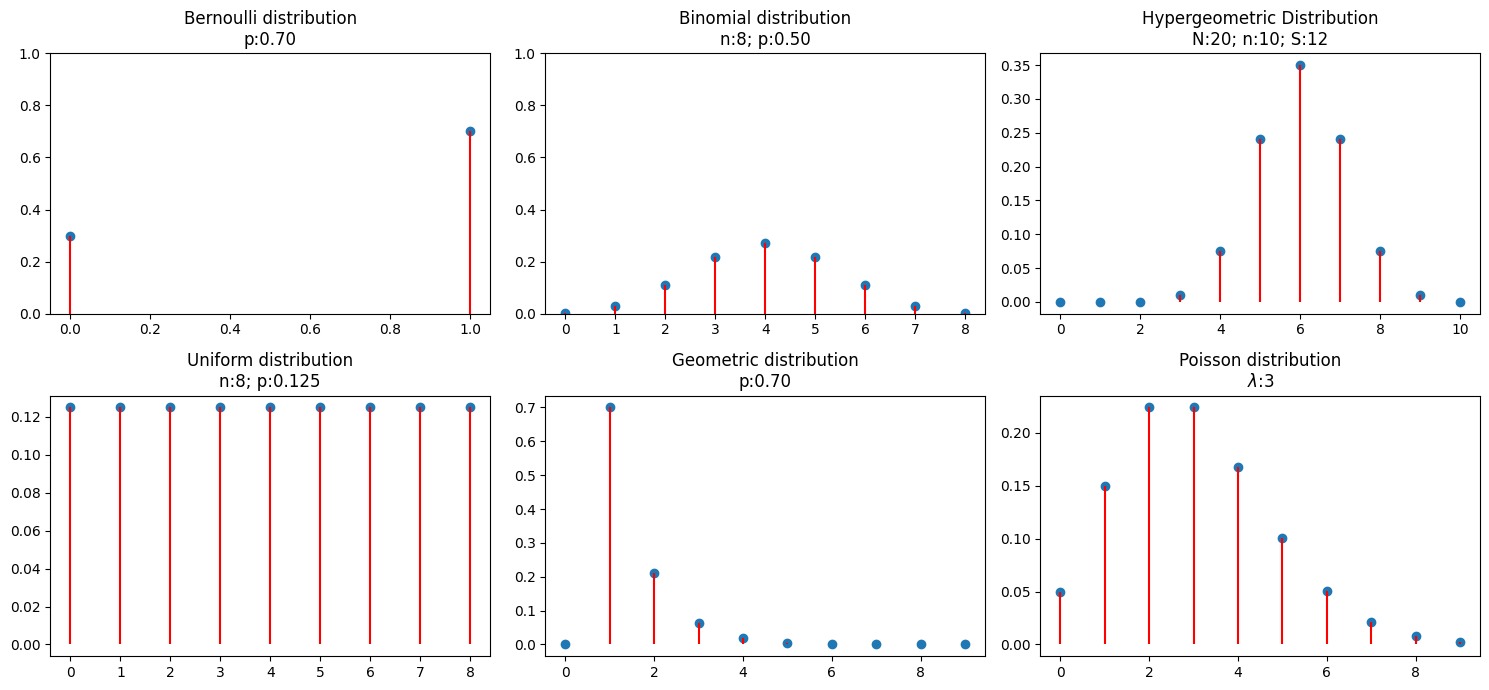

In [44]:
fig, ax = plt.subplots(2,3, figsize=(15,7))

# Bernoulli
p = 0.7

ax[0,0].scatter([0, 1], [1-p, p])
for i,j in zip((0,1), (1-p,p)):
  ax[0,0].vlines(i,0,j, color='red')
ax[0,0].set_title(f'Bernoulli distribution\np:{p:.2f}')
ax[0,0].set_ylim(0,1)

# Binomial
n = 8
p = 0.5

x = np.arange(n+1)
probs = scipy.stats.binom.pmf(x, n, p)

ax[0,1].scatter(x, probs)
for i,j in zip(x, probs):
  ax[0,1].vlines(i,0,j, color='red')
ax[0,1].set_title(f'Binomial distribution\nn:{n}; p:{p:.2f}')
ax[0,1].set_ylim(0,1)


# Hypergeometric
N = 20 # Population
n = 10 # Sample
S = 12 # Succesful population
x = np.arange(n+1)

probs = scipy.stats.hypergeom.pmf(x, N, n, S)

ax[0,2].scatter(x, probs)
for i,j in zip(x, probs):
  ax[0,2].vlines(i,0,j, color='red')
ax[0,2].set_title(f'Hypergeometric Distribution\nN:{N}; n:{n}; S:{S}')

# Uniform
n = 8
p = 1/n

ax[1,0].scatter(np.arange(n+1), [p]*(n+1))
for i,j in zip(np.arange(n+1), [p]*(n+1)):
  ax[1,0].vlines(i,0,j, color='red')
ax[1,0].set_title(f'Uniform distribution\nn:{n}; p:{p}')

# Geometric
p = 0.7
x = np.arange(10)

probs = scipy.stats.geom.pmf(x, p)

ax[1,1].scatter(x, probs)
for i,j in zip(x, probs):
  ax[1,1].vlines(i,0,j, color='red')
ax[1,1].set_title(f'Geometric distribution\np:{p:.2f}')

# Poisson
l = 3
x = np.arange(10)
probs = scipy.stats.poisson.pmf(x, l)

ax[1,2].scatter(x, probs)
for i,j in zip(x, probs):
  ax[1,2].vlines(i,0,j, color='red')
ax[1,2].set_title(f'Poisson distribution\n' + r'$\lambda$:' + f'{l}')


plt.tight_layout()
plt.show()

##Continous distribution

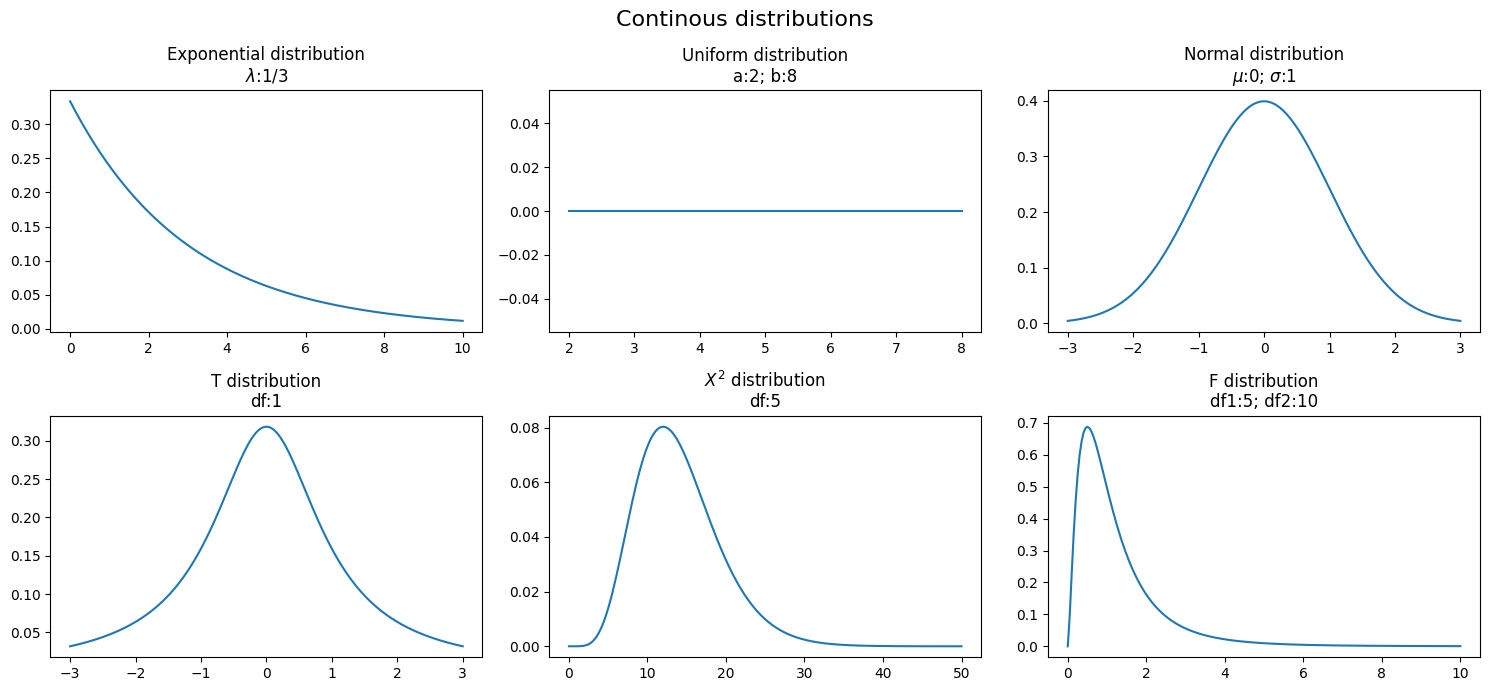

In [86]:
fig, ax = plt.subplots(2, 3, figsize=(15, 7))

# Exponencial Distribution

x = np.linspace(0, 10, 200)
l = 3
probs = scipy.stats.expon.pdf(x, scale=l)

ax[0,0].plot(x, probs)
ax[0,0].set_title(f'Exponential distribution\n' + r'$\lambda$:' + f'1/{l}')

# Uniform Distribution

a = 2
b = 8

x = np.linspace(a, b, 200)
probs = scipy.stats.uniform.pdf(x)

ax[0,1].plot(x, probs)
ax[0,1].set_title(f'Uniform distribution\na:{a}; b:{b}')


# Normal Distribution

x = np.linspace(-3, 3, 200)
u = 0
sd = 1
probs = scipy.stats.norm.pdf(x, loc=u, scale=sd)

ax[0,2].plot(x, probs)
ax[0,2].set_title(f'Normal distribution\n' + r'$\mu$:' + f'{u}; ' + r'$\sigma$:' + f'{sd}')


# T Distribution

x = np.linspace(-3, 3, 200)
df = 1
probs = scipy.stats.t.pdf(x, df=df)

ax[1,0].plot(x, probs)
ax[1,0].set_title(f'T distribution\ndf:{df}')


# X2 Distribution

x = np.linspace(0, 50, 200)
df = 14
probs = scipy.stats.chi2.pdf(x, df=df)

ax[1,1].plot(x, probs)
ax[1,1].set_title(f'$X^2$ distribution\ndf:{df1}')


# F Distribution

x = np.linspace(0, 10, 200)
df1 = 5
df2 = 10
probs = scipy.stats.f.pdf(x, df1, df2)

ax[1,2].plot(x, probs)
ax[1,2].set_title(f'F distribution\ndf1:{df1}; df2:{df2}')

fig.suptitle('Continous distributions', fontsize=16)

plt.tight_layout()
plt.show()

##Normal distribution

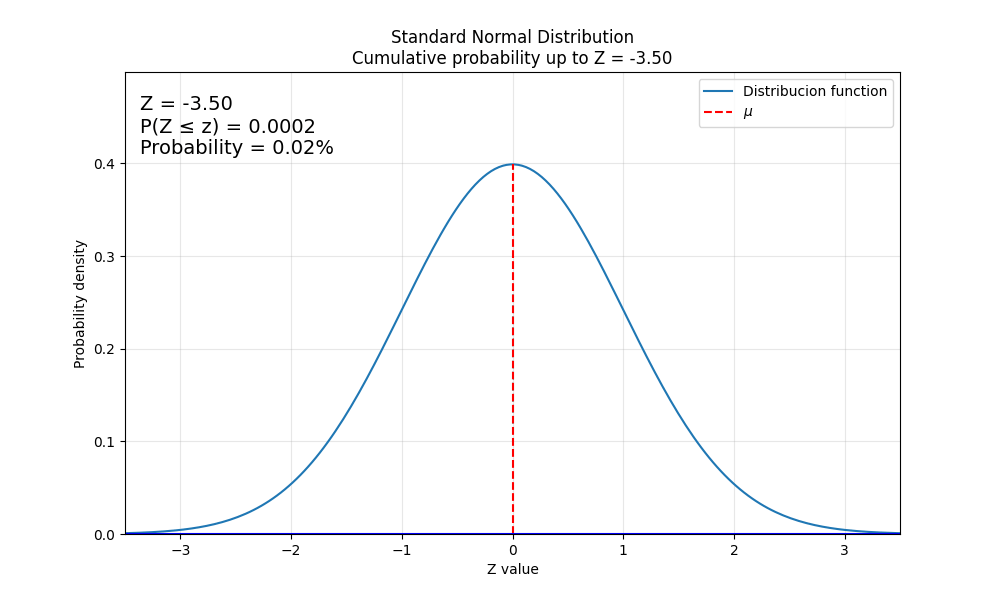

In [87]:
fig, ax = plt.subplots(figsize=(10, 6))


# 1. Defining the data

x = np.linspace(-3.5, 3.5, 200)
pdf = scipy.stats.norm.pdf(x)


# 2. Static aspects of the plot

ax.plot(x, pdf, label='Distribucion function')
ax.plot([0, 0], [0, np.max(pdf)], linestyle='--',
        label=r'$\mu$',color='red')
ax.axhline(0, color='blue')
ax.set_xlim(np.min(x), np.max(x))
ax.set_ylim(0, np.max(pdf) * 1.25)
ax.set_xlabel('Z value')
ax.set_ylabel('Probability density')
ax.set_title('Standard Normal Distribution')
ax.grid(alpha=0.3)
ax.text(0, np.max(pdf)*1.5, s=r'$mu$')
z_line, = ax.plot([], [], color='blue')


# 3. Dynamic components
# z_line = ax.axvline(
#     0,
#     linewidth=2
# )

polygon = Polygon(
    [[-3.5, 0], [-3.5, 0]],
    closed=True,
    alpha=0.4
)

ax.add_patch(polygon)

text = ax.text(
    0.02,
    0.95,
    '',
    transform=ax.transAxes,
    fontsize=14,
    verticalalignment='top'
)

ax.legend()


# 4. Defining the update function

def update(frame):

  z_value = x[frame]

  zx_value = x[:frame]
  zy_value = pdf[:frame]

  probability = scipy.stats.norm.cdf(z_value)



  z_line.set_data(zx_value, zy_value)

  mask = x <= z_value

  x_coords = x[mask]
  y_coords = pdf[mask]

  if len(x_coords) > 1:

      vertices = np.column_stack([
          np.r_[x_coords[0], x_coords, x_coords[-1]],
          np.r_[0, y_coords, 0]
      ])

      polygon.set_xy(vertices)

  text.set_text(
      f'Z = {z_value:.2f}\n'
      f'P(Z ≤ z) = {probability:.4f}\n'
      f'Probability = {probability * 100:.2f}%'
  )

  ax.set_title(
      'Standard Normal Distribution\n'
      f'Cumulative probability up to Z = {z_value:.2f}'
  )

  return z_line, polygon, text


# 5. Creating the animation

animation = FuncAnimation(
    fig=fig,
    func=update,
    frames=len(x),
    interval=30,
    blit=False,
    repeat=True
)


# 6. Exporting the figure

animation.save(
    filename='Standard Normal Distribution.gif',
    writer='pillow',
    fps=30
)

plt.close(fig)


# 7. Displaying the figure

display(
    Image(
        filename='Standard Normal Distribution.gif'
    )
)

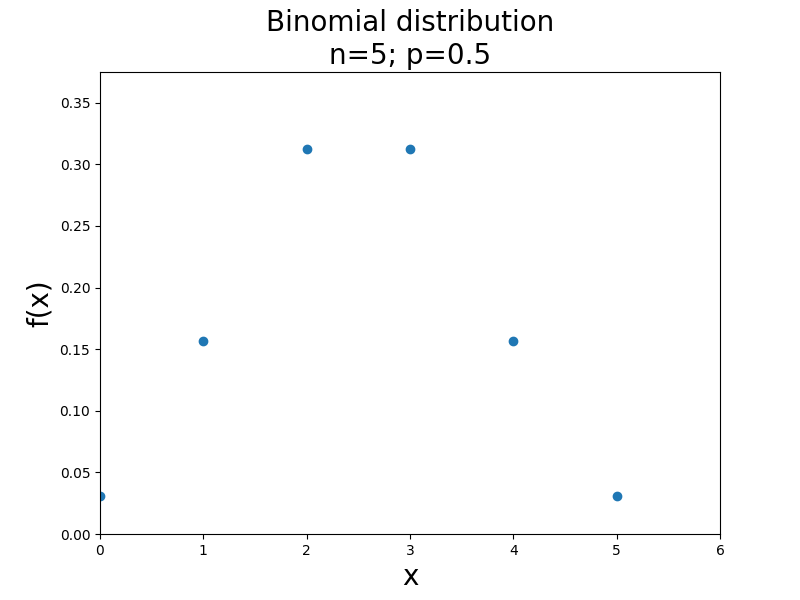

In [89]:
# Ley de los grandes numeros

p = 0.5
n = [5, 10, 20, 50, 100, 150]

x = [np.arange(i+1) for i in n]
fx = [scipy.stats.binom.pmf(x[i], n=n[i], p=p) for i in range(len(n))]

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter([], [])
ax.set_title('Binomial distribution', fontsize=20)
ax.set_xlabel('x', fontsize=20)
ax.set_ylabel('f(x)', fontsize=20)

def update(frame):

  scatter.set_offsets(np.column_stack([x[frame], fx[frame]]))

  ax.set_xlim(0, np.max(x[frame]) + 1)
  ax.set_ylim(0, np.max(fx[frame])*1.2)

  ax.set_title(f'Binomial distribution\nn={n[frame]}; p={p}', fontsize=20)

  return scatter,


animation = FuncAnimation(
    fig = fig,
    func = update,
    frames = len(n),
    interval=1000,
    blit=False,
    repeat=True
)

animation.save(
    filename='Binomial distribution.gif',
    writer='pillow',
    fps=2
)

plt.close(fig)

display(Image('Binomial distribution.gif'))


#Correlation analysis

In [92]:
np.arange(10, 30)

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29])

In [100]:
scipy.stats.uniform.rvs(1,4,size=40)

array([3.92429214, 1.64427606, 3.40279427, 4.46345783, 4.93408644,
       1.31746316, 2.7133891 , 1.81817144, 2.80254596, 3.19105429,
       1.37330684, 2.1874431 , 4.71033696, 3.27601493, 2.82964799,
       4.01410396, 3.96744861, 1.19431613, 3.83478958, 4.35697339,
       1.66375154, 4.12399175, 2.14614647, 2.22587901, 3.66104586,
       1.44556869, 3.6594898 , 4.55142717, 3.78524507, 2.76131151,
       2.75285754, 4.06038438, 3.262568  , 1.33961665, 3.33068435,
       4.25937481, 2.34826553, 4.71030632, 4.002868  , 3.2962553 ])

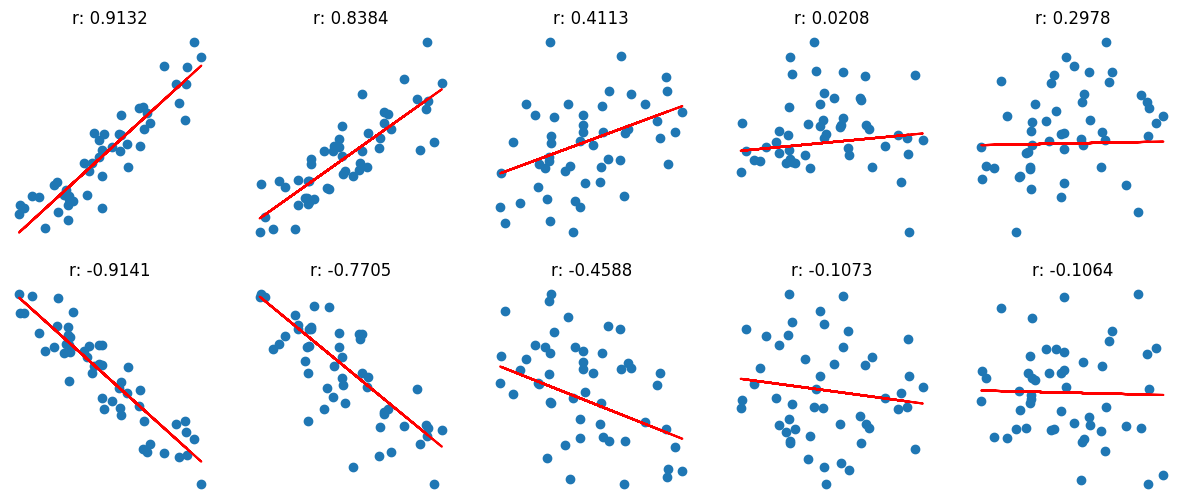

In [166]:
sd = [0.5, 1, 3, 10, 50]

np.random.seed(3)
random.seed(3)

x = scipy.stats.uniform.rvs(loc=0, scale=5, size=50)
y1 = x + 5
y2 = -x + 5

dim = int(len(sd))

fig, ax = plt.subplots(2, dim, figsize=(15, 6))


for i in range(dim):
  noise = scipy.stats.norm.rvs(size=len(x), loc=0, scale=sd[i])
  cor = np.corrcoef(x, y1+noise)
  ax[0, i].scatter(x, y1+noise)
  ax[0,i].plot(x, y1, color='red')
  ax[0, i].set_title(f'r: {cor[0,1]:.4f}')
  ax[0, i].axis('off')

for i in range(dim):
  noise = scipy.stats.norm.rvs(size=len(x), loc=0, scale=sd[i])
  cor = np.corrcoef(x, y2+noise)
  ax[1, i].scatter(x, y2+noise)
  ax[1, i].plot(x, y2, color='red')
  ax[1, i].set_title(f'r: {cor[0,1]:.4f}')
  ax[1, i].axis('off')

plt.show()

#Regression analysis

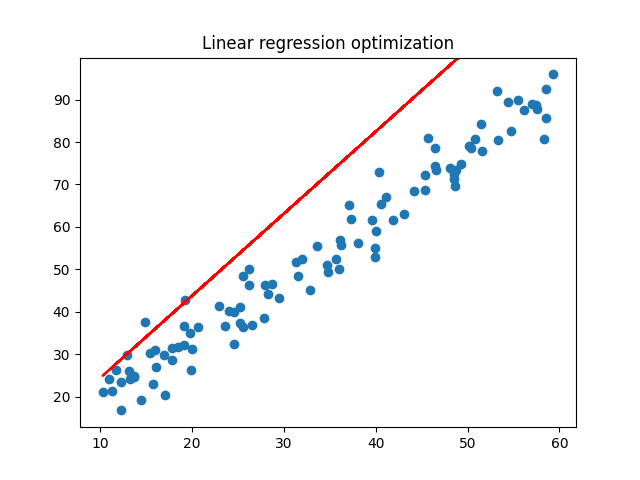

In [284]:
np.random.seed(42)
random.seed(42)

n = 100
x = scipy.stats.uniform.rvs(10, 50, size=n)
noise = scipy.stats.norm.rvs(scale=5, size=n)
y = 1.5*x + 3 + noise

lr = 0.00001
epsilon = 0.01

B0 = random.randint(0,5)
B1 = random.randint(0,5)
error = 999
residuos = 1

l_B0 = []
l_B1 = []
l_error = []

i=0
while abs(np.sum(residuos))>epsilon:


  y_pred = B0 + B1 * x

  residuos = y - y_pred

  dB0 = -np.sum(residuos)
  dB1 = -np.sum(x * residuos)

  B0 -= lr * dB0
  B1 -= lr * dB1

  l_B0.append(B0)
  l_B1.append(B1)
  l_error.append(error)

  error = 0.5 * np.sum((y - y_pred)**2)

  # time.sleep(0.5)

  # print(f'Epoca:{i} | B0:{B0:.4f} | B1:{B1:.4f} | error:{error:.4f}')

  i += 1


fig, ax = plt.subplots()
ax.scatter(x, y)
line, = ax.plot([], [], color='red')

ax.set_title('Linear regression optimization')

frames = np.linspace(0, len(l_B0) - 1, 1000, dtype=int)

def update(frame):

  line.set_data(x, l_B0[frame] + l_B1[frame]*x)

  return line,


animation = FuncAnimation(
    fig = fig,
    func = update,
    frames = frames,
    interval=50,
    blit=False,
    repeat=True
)

animation.save(
    filename='Regression optimization.gif',
    writer='pillow',
    fps=120
)

plt.close(fig)

display(Image('Regression optimization.gif'))